In [2]:
import importlib
import numpy as np
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data, split_input_target_interactions
from teaser import load_item_tag_matrix
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint, set_seed

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
#device = torch.device("cpu")

DATASET = "MSD"
ELSA_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-26b50839.ckpt"  # ELSA + L2
MULTVAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-369a6053.ckpt"  # MultVAE + L2
#TEASER_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TEASERGD-1753-51af622f.ckpt"  # TEASER-GD
TEASER_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TEASERGD-1753-97a505a1.ckpt"  # TEASER-GD

elsa_sae_cfg = load_config_from_checkpoint(ELSA_CHECKPOINT_PATH)
elsa_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{elsa_sae_cfg['pretrained_model_checkpoint']}"
elsa_cfg = load_config_from_checkpoint(elsa_checkpoint_path)
multvae_sae_cfg = load_config_from_checkpoint(MULTVAE_CHECKPOINT_PATH)
multvae_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{multvae_sae_cfg['pretrained_model_checkpoint']}"
multvae_cfg = load_config_from_checkpoint(multvae_checkpoint_path)
teaser_cfg = load_config_from_checkpoint(TEASER_CHECKPOINT_PATH)

set_seed(elsa_cfg["seed"])

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(
    elsa_cfg
)  # both models use the same dataset configuration
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/song_names.csv").rename({"song_id": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)


elsa_model_class = getattr(importlib.import_module(elsa_cfg["model_module"]), elsa_cfg["model_class"])
elsa_model = elsa_model_class(train_csr.shape[1], elsa_cfg["embedding_dim"]).to(device)
multvae_model_class = getattr(importlib.import_module(multvae_cfg["model_module"]), multvae_cfg["model_class"])
multvae_model = multvae_model_class(
    train_csr.shape[1],
    [int(x) for x in multvae_cfg["hidden_dims"].split(",") if x.strip()],
    multvae_cfg["embedding_dim"],
    multvae_cfg["annealing_beta"],
    multvae_cfg["annealing_steps"],
).to(device)
_, _ = load_checkpoint(elsa_model, None, get_checkpoint_filepath(elsa_cfg), device, None)
_, _ = load_checkpoint(multvae_model, None, get_checkpoint_filepath(multvae_cfg), device, None)

elsa_sae_model_class = getattr(importlib.import_module(elsa_sae_cfg["model_module"]), elsa_sae_cfg["model_class"])
elsa_sae = elsa_sae_model_class(
    elsa_cfg["embedding_dim"],
    elsa_sae_cfg["embedding_dim"],
    elsa_sae_cfg["reconstruction_loss"],
    l1_coef=elsa_sae_cfg["l1_coef"],
    k=elsa_sae_cfg["k"],
).to(device)
multvae_sae_model_class = getattr(importlib.import_module(multvae_sae_cfg["model_module"]), multvae_sae_cfg["model_class"])
multvae_sae = multvae_sae_model_class(
    multvae_cfg["embedding_dim"],
    multvae_sae_cfg["embedding_dim"],
    multvae_sae_cfg["reconstruction_loss"],
    l1_coef=multvae_sae_cfg["l1_coef"],
    k=multvae_sae_cfg["k"],
).to(device)
_, _ = load_checkpoint(elsa_sae, None, get_checkpoint_filepath(elsa_sae_cfg), device, None)
_, _ = load_checkpoint(multvae_sae, None, get_checkpoint_filepath(multvae_sae_cfg), device, None)

teaser_model_class = getattr(importlib.import_module(teaser_cfg["model_module"]), teaser_cfg["model_class"])
teaser_item_tag_matrix, teaser_tags = load_item_tag_matrix(teaser_cfg["dataset"], items, teaser_cfg["tag_min_count"], weighted=False)
teaser_model = teaser_model_class(
    teaser_item_tag_matrix.to(device),
    lambda1=teaser_cfg["lambda1"],
    lambda2=teaser_cfg["lambda2"],
    init_std=teaser_cfg["init_std"],
).to(device)
_, _ = load_checkpoint(teaser_model, None, get_checkpoint_filepath(teaser_cfg), device, None)

test_inputs, test_targets = split_input_target_interactions(test_csr, elsa_cfg["target_interaction_ratio"])

cf_models = {"ELSA": elsa_model, "MultVAE": multvae_model}
sae_models = {"ELSA": elsa_sae, "MultVAE": multvae_sae}
direct_models = {"TEASER": teaser_model}

Removing items with < 200 interactions...
Removing users with < 20 interactions...
Dataset info: users=571355, items=41140, interactions=33633450
Train split info: users=457084, items=41140, interactions=26896271
Val split info: users=57136, items=41140, interactions=3383422
Test split info: users=57135, items=41140, interactions=3353757
Loaded checkpoint from checkpoints/MSD/ELSA-1024-b9aa5195.ckpt (after 25 epochs)
Loaded checkpoint from checkpoints/MSD/MultVAE-1024-da1abc6f.ckpt (after 25 epochs)
Loaded checkpoint from checkpoints/MSD/TopKSAE-8192-26b50839.ckpt (after 97 epochs)
Loaded checkpoint from checkpoints/MSD/TopKSAE-8192-369a6053.ckpt (after 999 epochs)
Loaded checkpoint from checkpoints/MSD/TEASERGD-1753-97a505a1.ckpt (after 24 epochs)


In [3]:
from elsa import ELSA


sparse_item_embedding_dict = {}

for base_model_name in cf_models:
    print(base_model_name)
    sparse_item_embeddings = []
    onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
    with torch.no_grad():
        for onehot_batch in tqdm(onehot_items_dataloader):
            cf_model = cf_models[base_model_name]
            user_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
            if cf_model.__class__ != ELSA:
                user_embedding = user_embedding[0]
            sae = sae_models[base_model_name]
            sae_embedding, _, input_mean, input_std = sae.encode(user_embedding)
            sparse_item_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
    sparse_item_embeddings = sp.vstack(sparse_item_embeddings)
    sparse_item_embedding_dict[base_model_name] = sparse_item_embeddings

    neuron_is_alive = np.asarray(sparse_item_embeddings.sum(axis=0)).flatten() != 0
    living_neurons = np.where(neuron_is_alive)[0]
    dead_neuron_count = sparse_item_embeddings.shape[1] - neuron_is_alive.sum()
    print(f"{dead_neuron_count} dead neurons out of {sparse_item_embeddings.shape[1]} ({dead_neuron_count / sparse_item_embeddings.shape[1]:.2%})")
    print(f"{neuron_is_alive.sum()} alive ones\n")

ELSA


100%|██████████| 41/41 [00:02<00:00, 13.78it/s]


1730 dead neurons out of 8192 (21.12%)
6462 alive ones

MultVAE


100%|██████████| 41/41 [00:03<00:00, 12.66it/s]

5806 dead neurons out of 8192 (70.87%)
2386 alive ones



In [4]:
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/song_tag_assignment.csv")
    .rename({"song_id": "item_id"})
    .cast({"item_id": pl.String})
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars().alias("tag"))
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .collect()
    .with_columns(pl.col("tag").cast(pl.Categorical))
)

tag_df


item_id,tag,weight,item_idx
str,cat,f64,i64
"""SONCXZL12A8C13F6B9""","""classic rock""",1.0,11262
"""SOZMEWR12A6701EBD9""","""classic rock""",1.0,11631
"""SOBUOEK12A6D4F9908""","""classic rock""",1.0,4906
"""SONYAFR12AB017F05A""","""classic rock""",1.0,13598
"""SOQJHUW12AB0188A24""","""classic rock""",1.0,7979
…,…,…,…
"""SOCVHZE12AB01825AB""","""outskirts of expansion""",33.0,21814
"""SOBEMUS12AB0183B42""","""outskirts of expansion""",50.0,21865
"""SOHKXSO12AB0189B61""","""outskirts of expansion""",100.0,26649


In [5]:
def get_tag_item_counts(tag_df: pl.DataFrame, user_subset = None) -> tuple[np.ndarray, sp.csr_matrix]:
    #tags = tag_df["tag"].unique(maintain_order=True).to_numpy()
    tags = tag_df["tag"].cat.get_categories().to_numpy()
    num_tags = len(tags)
    num_items = len(items)
    #if user_subset is not None: #not known for MSD data
    #    tag_df = tag_df.filter(pl.col("user_id").is_in(user_subset))
    row_idx = tag_df["tag"].to_physical().to_numpy()
    
    col_idx = tag_df["item_idx"].to_numpy()
    data    = tag_df["weight"].cast(pl.Float32).to_numpy()
    
    tag_item_counts = sp.csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(num_tags, num_items),
    )
    return tags, tag_item_counts


tags, train_tag_item_counts = get_tag_item_counts(tag_df, user_subset=train_users)

tags, train_tag_item_counts

(array(['classic rock', 'progressive rock', 'blues', ..., '6070',
        'outskirts of expansion', 'huumoria'], shape=(1753,), dtype=object),
 <Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 692080 stored elements and shape (1753, 41140)>)

In [6]:

from sae import SAE


class SAESteeredModel:
    def __init__(self, base_model, sae: SAE, concept_neuron_mapping: torch.Tensor, alpha: float):
        self.base_model = base_model
        self.sae = sae
        self.concept_neuron_mapping = concept_neuron_mapping  # shape: (num_tags,) or (num_tags, top_n)
        self.alpha = alpha  # total steering strength

    def eval(self):
        self.base_model.eval()

    @torch.no_grad()
    def encode(self, interaction_batch: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        user_embeddings = self.base_model.encode(interaction_batch)
        if self.base_model.__class__ != ELSA:
            user_embeddings = user_embeddings[0]
        sae_embeddings, _, input_mean, input_std = self.sae.encode(user_embeddings)
        return sae_embeddings, input_mean, input_std

    @torch.no_grad()
    def decode(self, sae_embeddings: torch.Tensor, input_mean: torch.Tensor, input_std: torch.Tensor) -> torch.Tensor:
        return self.base_model.decode(self.sae.decode(sae_embeddings, input_mean, input_std))

    @torch.no_grad()
    def recommend(self, batch: tuple[torch.Tensor, torch.Tensor], k: int, mask_interactions: bool = True) -> tuple[torch.Tensor, torch.Tensor]:
        interaction_batch, steering_concept_id_batch = batch

        sae_embeddings, input_mean, input_std = self.encode(interaction_batch)
        neuron_batch = self.concept_neuron_mapping[steering_concept_id_batch]

        if neuron_batch.ndim == 1:
            neuron_batch = neuron_batch.unsqueeze(1)

        s = sae_embeddings.sum(-1, keepdim=True)
        s_safe = torch.where(s == 0, torch.ones_like(s), s)

        # preserve total activation mass and spread the steering budget uniformly over selected neurons
        sae_embeddings = sae_embeddings * ((1 - self.alpha) / s_safe)
        per_neuron_alpha = self.alpha / neuron_batch.shape[1]
        steering_mass = torch.full(
            size=neuron_batch.shape,
            fill_value=per_neuron_alpha,
            device=sae_embeddings.device,
            dtype=sae_embeddings.dtype,
        )
        sae_embeddings.scatter_add_(1, neuron_batch, steering_mass)
        sae_embeddings = sae_embeddings * s

        if self.base_model.__class__ != ELSA:
            scores = self.decode(sae_embeddings, input_mean, input_std)
        else:
            scores = nn.ReLU()(self.decode(sae_embeddings, input_mean, input_std) - interaction_batch)

        if mask_interactions:
            scores = torch.where(interaction_batch != 0, 0, scores)  # mask input interactions
        topk_scores, topk_indices = torch.topk(scores, k)
        return topk_scores.cpu().numpy(), topk_indices.cpu().numpy()


class TEASERSteeredModel:
    def __init__(self, base_model, alpha: float):
        self.base_model = base_model
        self.alpha = alpha

    def eval(self):
        self.base_model.eval()

    @torch.no_grad()
    def recommend(self, batch: tuple[torch.Tensor, torch.Tensor], k: int, mask_interactions: bool = True):
        interaction_batch, steering_concept_id_batch = batch
        profiles = self.base_model.user_profiles(interaction_batch)
        feedback = torch.zeros_like(profiles)
        feedback[torch.arange(feedback.shape[0]), steering_concept_id_batch] = self.alpha
        scores, _ = self.base_model.steer_scores(interaction_batch, feedback)
        if mask_interactions:
            scores = torch.where(interaction_batch != 0, 0, scores)
        topk_scores, topk_indices = torch.topk(scores, k)
        return topk_scores.cpu().numpy(), topk_indices.cpu().numpy()


In [7]:

def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0
    df = np.count_nonzero(X, axis=1)
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


def topk_per_row(matrix: np.ndarray, k: int) -> np.ndarray:
    """Return top-k column indices for each row, ordered from best to worst."""
    k = min(k, matrix.shape[1])
    idx = np.argpartition(-matrix, kth=k - 1, axis=1)[:, :k]
    vals = np.take_along_axis(matrix, idx, axis=1)
    order = np.argsort(-vals, axis=1)
    return np.take_along_axis(idx, order, axis=1)


TOP_N_STEERING_NEURONS = 10

train_tag_to_idx = {t: i for i, t in enumerate(tags)}

pti = train_tag_item_counts.copy()
pti.data /= pti.data.sum()

characteristic_neurons_per_tag_dict = {}
top_neurons_per_tag_dict = {}

for base_model_name in cf_models:
    print(base_model_name)
    sparse_item_embeddings = sparse_item_embedding_dict[base_model_name]
    neuron_is_alive = np.asarray(sparse_item_embeddings.sum(axis=0)).flatten() != 0

    tag_neuron_activity = pti @ sparse_item_embeddings  # tag x neuron
    tag_neuron_activity_dense = tag_neuron_activity.toarray()

    # neuron x tag and tag x neuron views of TF-IDF
    neuron_to_tag_tfidf = compute_tfidf(tag_neuron_activity_dense.T)
    tag_to_neuron_tfidf = compute_tfidf(tag_neuron_activity_dense)

    top_tag_per_neuron = tags[neuron_to_tag_tfidf.argmax(axis=1)]
    print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True).head(5))

    characteristic_tag_per_neuron = tags[tag_to_neuron_tfidf.argmax(axis=0)]
    print(pl.Series("characteristic_tag", characteristic_tag_per_neuron[neuron_is_alive]).value_counts(sort=True).head(5))

    # prevent dead neurons from being selected
    neuron_to_tag_tfidf[~neuron_is_alive, :] = -np.inf
    tag_to_neuron_tfidf[:, ~neuron_is_alive] = -np.inf

    if neuron_is_alive.sum() < TOP_N_STEERING_NEURONS:
        raise ValueError(
            f"{base_model_name} has only {neuron_is_alive.sum()} living neurons, fewer than TOP_N_STEERING_NEURONS={TOP_N_STEERING_NEURONS}."
        )

    # tag -> top-k neurons that best characterize the tag
    characteristic_neurons_per_tag = topk_per_row(neuron_to_tag_tfidf.T, TOP_N_STEERING_NEURONS)
    print(pl.Series("characteristic_neuron_top1", characteristic_neurons_per_tag[:, 0]).value_counts(sort=True).head(5))

    # tag -> top-k neurons whose firing is most unique to the tag
    top_neurons_per_tag = topk_per_row(tag_to_neuron_tfidf, TOP_N_STEERING_NEURONS)
    print(pl.Series("top_neuron_top1", top_neurons_per_tag[:, 0]).value_counts(sort=True).head(5))

    characteristic_neurons_per_tag_dict[base_model_name] = characteristic_neurons_per_tag
    top_neurons_per_tag_dict[base_model_name] = top_neurons_per_tag

characteristic_neurons_per_tag_dict["TEASER"] = np.repeat(np.arange(len(tags))[:, None], TOP_N_STEERING_NEURONS, axis=1)
top_neurons_per_tag_dict["TEASER"] = np.repeat(np.arange(len(tags))[:, None], TOP_N_STEERING_NEURONS, axis=1)


ELSA


/tmp/ipykernel_591623/837903430.py:9: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


shape: (5, 2)
┌────────────────────────────┬───────┐
│ top_tag                    ┆ count │
│ ---                        ┆ ---   │
│ str                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ baroque pop                ┆ 30    │
│ strings organs rubber wind ┆ 24    │
│ mistagged                  ┆ 23    │
│ new rave                   ┆ 22    │
│ balkan                     ┆ 21    │
└────────────────────────────┴───────┘
shape: (5, 2)
┌────────────────────┬───────┐
│ characteristic_tag ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ rock               ┆ 1008  │
│ indie              ┆ 595   │
│ electronic         ┆ 320   │
│ pop                ┆ 242   │
│ folk               ┆ 175   │
└────────────────────┴───────┘
shape: (5, 2)
┌────────────────────────────┬───────┐
│ characteristic_neuron_top1 ┆ count │
│ ---                        ┆ ---   │
│ i64                        ┆ u32   │
╞════════════════════════════╪══

In [8]:
from util import evaluate_ndcg_at_k, evaluate_recall_at_k


def evaluate_steering(
    model, inputs: sp.csr_matrix, targets: sp.csr_matrix, tag_df: pl.DataFrame, device: torch.device, k: int = 20, batch_size: int = 1024
) -> dict:
    tags, tag_item_counts = get_tag_item_counts(tag_df)
    tag_item_counts.data[:] = 1  # binarize
    item_tag_counts = tag_item_counts.T.astype(np.int64).toarray()
    input_tags_per_user = inputs.astype(np.int64) @ item_tag_counts
    target_tags_per_user = targets.astype(np.int64) @ item_tag_counts
    desired_tags_per_user = target_tags_per_user - input_tags_per_user
    desired_tags_per_user[desired_tags_per_user < 0] = 0
    desired_tags_per_user = torch.tensor(desired_tags_per_user)
    values, indices = torch.topk(desired_tags_per_user, k=1)
    if values.min() > 0:
        print(input_tags_per_user)
        print(target_tags_per_user)
        print(desired_tags_per_user)
        print(values, indices)

    segment_inputs = indices.numpy().flatten()  # 1 desired concept id for each user
    segment_targets = tag_item_counts[indices.numpy().flatten()]

    personal_inputs = Dataloader(inputs, batch_size, device)
    steering_inputs = Dataloader(segment_inputs, batch_size, device)
    personal_targets = Dataloader(targets, batch_size, device)
    segment_targets = Dataloader(segment_targets, batch_size, device)


    # Personal targets (binary)
    personal_target_matrix = targets.copy().tocsr()
    personal_target_matrix.data[:] = 1
    
    # Segment targets (binary)
    segment_targets = tag_item_counts[segment_inputs].tocsr()
    segment_targets.data[:] = 1
    
    # personalSegment = intersection(personal, segment)
    personal_segment_targets = personal_target_matrix.multiply(segment_targets).tocsr()
    personal_segment_targets.data[:] = 1
    personal_segment_targets.eliminate_zeros()
    
    # personalNotSegment = personal \ segment
    personal_not_segment_targets = (personal_target_matrix - personal_segment_targets).tocsr()
    personal_not_segment_targets.eliminate_zeros()
    if personal_not_segment_targets.nnz > 0:
        personal_not_segment_targets.data[:] = 1

    
    personal_targets_dl = Dataloader(personal_target_matrix, batch_size, device)
    segment_targets_dl = Dataloader(segment_targets, batch_size, device)
    personal_segment_targets_dl = Dataloader(personal_segment_targets, batch_size, device)
    personal_not_segment_targets_dl = Dataloader(personal_not_segment_targets, batch_size, device)

    
    model.eval()

    
    personal_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), personal_targets_dl, k)
    segment_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), segment_targets_dl, k)
    
    personal_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), personal_targets_dl, k)
    segment_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), segment_targets_dl, k)
    
    personal_segment_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), personal_segment_targets_dl, k)
    personal_segment_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), personal_segment_targets_dl, k)
    
    personal_not_segment_recalls = evaluate_recall_at_k(model, zip(personal_inputs, steering_inputs), personal_not_segment_targets_dl, k)
    personal_not_segment_ndcgs = evaluate_ndcg_at_k(model, zip(personal_inputs, steering_inputs), personal_not_segment_targets_dl, k)
    


    results = {
        f"recall@{k}(personal)": {
            "mean": float(np.mean(personal_recalls)),
            "se": float(np.std(personal_recalls) / np.sqrt(len(personal_recalls)))
        },
        f"ndcg@{k}(personal)": {
            "mean": float(np.mean(personal_ndcgs)),
            "se": float(np.std(personal_ndcgs) / np.sqrt(len(personal_ndcgs)))
        },
    
        f"recall@{k}(segment)": {
            "mean": float(np.mean(segment_recalls)),
            "se": float(np.std(segment_recalls) / np.sqrt(len(segment_recalls)))
        },
        f"ndcg@{k}(segment)": {
            "mean": float(np.mean(segment_ndcgs)),
            "se": float(np.std(segment_ndcgs) / np.sqrt(len(segment_ndcgs)))
        },
    
        f"recall@{k}(personalSegment)": {
            "mean": float(np.mean(personal_segment_recalls)),
            "se": float(np.std(personal_segment_recalls) / np.sqrt(len(personal_segment_recalls)))
        },
        f"ndcg@{k}(personalSegment)": {
            "mean": float(np.mean(personal_segment_ndcgs)),
            "se": float(np.std(personal_segment_ndcgs) / np.sqrt(len(personal_segment_ndcgs)))
        },
    
        f"recall@{k}(personalNotSegment)": {
            "mean": float(np.mean(personal_not_segment_recalls)),
            "se": float(np.std(personal_not_segment_recalls) / np.sqrt(len(personal_not_segment_recalls)))
        },
        f"ndcg@{k}(personalNotSegment)": {
            "mean": float(np.mean(personal_not_segment_ndcgs)),
            "se": float(np.std(personal_not_segment_ndcgs) / np.sqrt(len(personal_not_segment_ndcgs)))
        },
    }
    return results

In [9]:

results = {}
STEERING_LEVELS_ELSA = [1, 5, 10]

for base_model_name in cf_models:
    print(base_model_name)
    cf_model = cf_models[base_model_name]
    sae = sae_models[base_model_name]
    characteristic_neurons_per_tag = characteristic_neurons_per_tag_dict[base_model_name]
    top_neurons_per_tag = top_neurons_per_tag_dict[base_model_name]

    variant_names = []
    if base_model_name == "ELSA":
        variant_names.extend([f"map: best characterizes (top-{n})" for n in STEERING_LEVELS_ELSA])
    else:
        variant_names.append("map: best characterizes")
    variant_names.append("map: most unique")

    results[base_model_name] = {name: {} for name in variant_names}

    if base_model_name == "ELSA":
        for top_n in STEERING_LEVELS_ELSA:
            mapping = characteristic_neurons_per_tag[:, :top_n]
            for alpha in tqdm(np.linspace(0, 0.5, 6), desc=f"{base_model_name} best characterizes top-{top_n}"):
                res = results[base_model_name][f"map: best characterizes (top-{top_n})"]
                a = float(alpha)
                m = SAESteeredModel(
                    base_model=cf_model,
                    sae=sae,
                    concept_neuron_mapping=torch.tensor(mapping, dtype=torch.long, device=device),
                    alpha=a,
                )
                res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)
    else:
        mapping = characteristic_neurons_per_tag[:, :1]
        for alpha in tqdm(np.linspace(0, 0.5, 6), desc=f"{base_model_name} best characterizes"):
            res = results[base_model_name]["map: best characterizes"]
            a = float(alpha)
            m = SAESteeredModel(
                base_model=cf_model,
                sae=sae,
                concept_neuron_mapping=torch.tensor(mapping, dtype=torch.long, device=device),
                alpha=a,
            )
            res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)

    mapping = top_neurons_per_tag[:, :1]
    for alpha in tqdm(np.linspace(0, 0.5, 6), desc=f"{base_model_name} most unique"):
        res = results[base_model_name]["map: most unique"]
        a = float(alpha)
        m = SAESteeredModel(
            base_model=cf_model,
            sae=sae,
            concept_neuron_mapping=torch.tensor(mapping, dtype=torch.long, device=device),
            alpha=a,
        )
        res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)

for base_model_name, cf_model in direct_models.items():
    print(base_model_name)
    results[base_model_name] = {"map: direct tag": {}}
    for alpha in tqdm(np.linspace(0, 0.5, 6), desc=f"{base_model_name} direct tag"):
        res = results[base_model_name]["map: direct tag"]
        a = float(alpha)
        m = TEASERSteeredModel(base_model=cf_model, alpha=a)
        res[a] = evaluate_steering(m, test_inputs, test_targets, tag_df, device)

results


ELSA


ELSA most unique: 100%|██████████| 6/6 [05:35<00:00, 55.90s/it]


MultVAE


MultVAE most unique: 100%|██████████| 6/6 [06:24<00:00, 64.07s/it]


TEASER


TEASER direct tag: 100%|██████████| 6/6 [05:54<00:00, 59.16s/it]


{'ELSA': {'map: best characterizes (top-1)': {0.0: {'recall@20(personal)': {'mean': 0.2587141692638397,
     'se': 0.0009288911507072689},
    'ndcg@20(personal)': {'mean': 0.25533685088157654,
     'se': 0.0009403575919844703},
    'recall@20(segment)': {'mean': 0.05726977437734604,
     'se': 0.00032955989673674984},
    'ndcg@20(segment)': {'mean': 0.06292617321014404,
     'se': 0.00037950087944930956},
    'recall@20(personalSegment)': {'mean': nan, 'se': nan},
    'ndcg@20(personalSegment)': {'mean': 0.12116274982690811,
     'se': 0.0009077745532491307},
    'recall@20(personalNotSegment)': {'mean': nan, 'se': nan},
    'ndcg@20(personalNotSegment)': {'mean': 0.23658621311187744,
     'se': 0.0009389608572124843}},
   0.1: {'recall@20(personal)': {'mean': 0.2500068247318268,
     'se': 0.0009141580145500479},
    'ndcg@20(personal)': {'mean': 0.2490849494934082,
     'se': 0.0009249994318226106},
    'recall@20(segment)': {'mean': 0.1043640524148941,
     'se': 0.000535692015510

In [10]:
import matplotlib.pyplot as plt


def plot(data: dict[str, dict], metric_x: str, metric_y: str, path = None):
    fig, ax = plt.subplots(figsize=(4, 2.5))

    # Iterate over variants and plot each with its own color
    for variant, res in data.items():
        params = sorted(res.keys())
        x = [res[p][metric_x]["mean"] for p in params]
        y = [res[p][metric_y]["mean"] for p in params]
        xerr = [res[p][metric_x]["se"] for p in params]
        yerr = [res[p][metric_y]["se"] for p in params]

        line = ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o-", lw=1, capsize=2, markersize=4, label=variant)

        # Add parameter labels
        color = line[0].get_color()
        for i, p in enumerate(params):
            ax.text(x[i], y[i], f"{round(p, 3)}", fontsize=7, va="bottom", ha="left", color=color)

    # Axis setup
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)
    ax.set_xlim(0.0, 0.45)
    ax.set_ylim(0.0, 0.45)
    # ax.set_aspect("equal", adjustable="box")

    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()

    if path:
        fig.savefig(path, dpi=600, bbox_inches="tight")

    plt.show()

In [13]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _fmt_alpha(a):
    # Pretty alpha label: 0.3 instead of 0.30000000000000004
    s = f"{float(a):.3f}".rstrip("0").rstrip(".")
    return s if s else "0"


def plot_results(
    data: dict,
    metric_x: str,
    metric_y: str,
    path: str | None = None,
    xlim=None,
    ylim=None,
    annotate=True,
):
    """
    data:
      { base_model: {
          "map: best characterizes": { alpha: {metric_x:{mean,se}, metric_y:{mean,se}, ...}, ... },
          "map: most unique":        { alpha: {...}, ... }
        }, ... }
    """

    color_by_model = {"ELSA": "tab:orange", "MultVAE": "tab:blue", "TEASER": "tab:green"}
    style_by_map = {
        "map: best characterizes (top-10)": dict(linestyle="-.", marker="o"),
        "map: best characterizes (top-1)": dict(linestyle="-", marker="D"),        
        "map: most unique": dict(linestyle="--", marker="s"),
        "map: direct tag": dict(linestyle=":", marker="^"),
    }

    fig, ax = plt.subplots(figsize=(5, 2.8))

    all_x, all_y = [], []

    for base_model, maps in data.items():
        color = color_by_model.get(base_model, None)
        for map_type, series in maps.items():
            if not series:
                continue
            print(map_type)
            if map_type == "map: best characterizes":
                map_type = "map: best characterizes (top-1)"
            
            style = style_by_map.get(map_type, dict(linestyle="-", marker="o"))

            # Sort alphas numerically
            alphas = sorted(series.keys(), key=float)

            # Extract, skipping points missing either metric
            x, y, xerr, yerr, alphas_kept = [], [], [], [], []
            for a in alphas:
                rec = series[a]
                if metric_x in rec and metric_y in rec:
                    x.append(rec[metric_x]["mean"])
                    y.append(rec[metric_y]["mean"])
                    all_x.append(rec[metric_x]["mean"])
                    all_y.append(rec[metric_y]["mean"])
                    xerr.append(rec[metric_x].get("se", 0.0))
                    yerr.append(rec[metric_y].get("se", 0.0))
                    alphas_kept.append(a)

            if not x:
                continue

            line = ax.errorbar(x, y, xerr=xerr, yerr=yerr, lw=1, capsize=2, markersize=4, color=color, label=f"{base_model} • {map_type}", **style)

            if annotate:
                tcolor = color if color is not None else line[0].get_color()
                for xi, yi, a in zip(x, y, alphas_kept):
                    ax.text(xi, yi, f" {_fmt_alpha(a)}", fontsize=7, va="bottom", ha="left", color=tcolor)

    # Axes & layout
    ax.set_xlabel(metric_x)
    ax.set_ylabel(metric_y)
    ax.grid(True, ls="--", lw=0.4, alpha=0.6)

    if xlim is None and all_x:
        xmin, xmax = min(all_x), max(all_x)
        xpad = max((xmax - xmin) * 0.12, 0.005)
        ax.set_xlim(max(0.0, xmin - xpad), xmax + xpad)
    elif xlim is not None:
        ax.set_xlim(*xlim)

    if ylim is None and all_y:
        ymin, ymax = min(all_y), max(all_y)
        ypad = max((ymax - ymin) * 0.12, 0.01)
        ax.set_ylim(max(0.0, ymin - ypad), ymax + ypad)
    elif ylim is not None:
        ax.set_ylim(*ylim)
    # ax.set_aspect("equal", adjustable="box")  # uncomment for equal scaling

    # Two legends: colors (base models) and styles (map types)
    color_handles = [Line2D([0], [0], color=c, lw=2, label=m) for m, c in color_by_model.items()]
    style_handles = [Line2D([0], [0], color="black", lw=2, linestyle=st["linestyle"], marker=st["marker"], label=mt.replace("map: ", "")) for mt, st in style_by_map.items()]
    leg1 = ax.legend(handles=color_handles, title="Base model", frameon=False, fontsize=8, loc="upper right")
    ax.add_artist(leg1)
    #ax.legend(handles=style_handles, title="Map type", frameon=False, fontsize=8, loc="upper right", bbox_to_anchor=(0.995, 0.67))

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=600, bbox_inches="tight")  # or .pdf/.svg for vector graphics
    plt.show()


def select_results_for_plot(results: dict) -> dict:
    selected = {}
    for base_model, maps in results.items():
        selected[base_model] = {}
        if base_model == "ELSA":
            for key in ["map: best characterizes (top-1)", "map: best characterizes (top-10)", "map: most unique"]:
                if key in maps:
                    selected[base_model][key] = maps[key]
        else:
            for key in ["map: best characterizes", "map: most unique", "map: direct tag"]:
                if key in maps:
                    selected[base_model][key] = maps[key]
        if not selected[base_model]:
            del selected[base_model]
    return selected


results_for_plot = select_results_for_plot(results)


map: best characterizes (top-1)
map: best characterizes (top-10)
map: most unique
map: best characterizes
map: most unique
map: direct tag


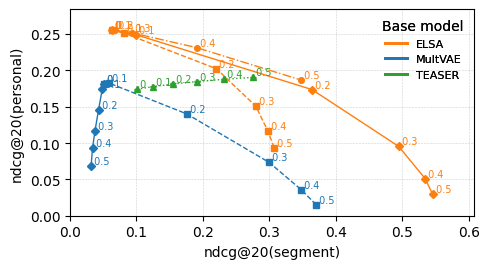

In [14]:
plot_results(data=results_for_plot, metric_x="ndcg@20(segment)", metric_y="ndcg@20(personal)", path="results/figures/steering_MSD.png")